In [19]:
### to create mba version of the plot using the new code

In [20]:
## automatically reload 
%reload_ext autoreload
%autoreload 2

In [21]:
import matplotlib.pyplot as plt
import numpy as np
import NEOMOD3 as nm3
import NEOfaster as nf
import neoscore as nsc
import S3Marray as sm
import S3M_fullversion as smfull
import trojans as tjn
import neoonlyS3M as neo3m

In [22]:
s3m = sm.define_s3m()

['S1_00.s3m', 'S1_01.s3m', 'S1_02.s3m', 'S1_03.s3m', 'S1_04.s3m', 'S1_05.s3m', 'S1_06.s3m', 'S1_07.s3m', 'S1_08.s3m', 'S1_09.s3m', 'S1_10.s3m', 'S1_11.s3m', 'S1_12.s3m', 'S1_13.s3m']
The final df is done.


In [23]:
s3m,array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m = sm.s3m_array(s3m)

In [24]:
scorer_mba_s3m = nsc.NEOMODScorer(array4D_s3m, H_center_s3m, a_center_s3m, e_center_s3m, i_center_s3m)

Starting computation...


Computing vlambda grid: 100%|██████████| 31/31 [02:14<00:00,  4.34s/it]

Computation complete!


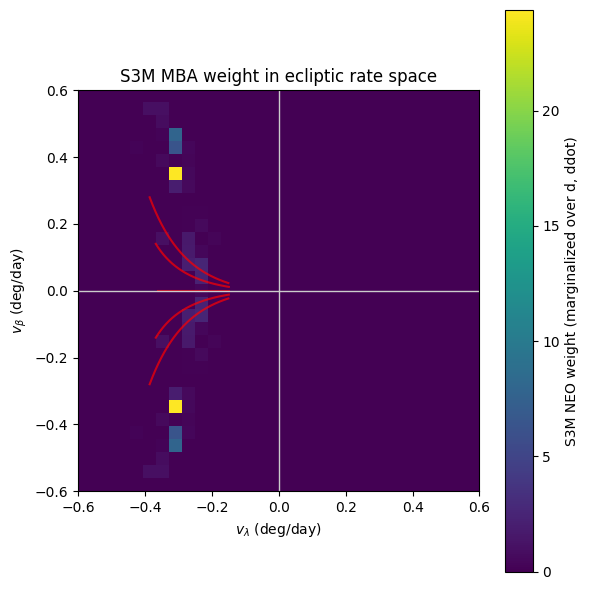

In [25]:
import numpy as np
import matplotlib.pyplot as plt
import neoscore as nsc
from tqdm import tqdm

# Observation params
obstime_str = "2025-09-23T00:00:00"
ra0_deg, dec0_deg = 0.0, 0.0
mag = 24.0

def comp_sum_with_scorer():
    """
    Compute marginalized weights over (vlambda, vbeta) grid using the scorer.
    """
    N_rate = 31
    vlam_min, vlam_max = -0.6, 0.6
    vbet_min, vbet_max = -0.6, 0.6
    vlam_vals = np.linspace(vlam_min, vlam_max, N_rate)
    vbet_vals = np.linspace(vbet_min, vbet_max, N_rate)
    
    K = np.zeros((len(vbet_vals), len(vlam_vals)), dtype=float)
    
    
    for i, vlam in enumerate(tqdm(vlam_vals, desc="Computing vlambda grid")):
        for j, vbet in enumerate(vbet_vals):
            # Convert ecliptic rates to RA/Dec rates
            dra, ddec = nsc.ecliptic_rates_to_radec_rates1(
                ra0_deg, dec0_deg, vlam, vbet, obstime_str
            )
            
            # Use the scorer's marginalization method
            w_int = scorer_mba_s3m.marginalize_over_distance(
                obstime_str=obstime_str,
                ra_deg=ra0_deg,
                dec_deg=dec0_deg,
                dra_deg_per_day=dra,
                ddec_deg_per_day=ddec,
                mag=mag
            )
            
            K[j, i] = w_int
    
    extent = [vlam_vals[0], vlam_vals[-1], vbet_vals[0], vbet_vals[-1]]
    return K, extent, vlam_vals, vbet_vals

# Compute the grid
print("Starting computation...")
K, extent, vlam_vals, vbet_vals = comp_sum_with_scorer()
print("Computation complete!")

# Prediction function 
vE_deg_per_day = 0.986  # Earth's orbital speed

def prediction_vlam_vbet(R_au, i_deg, phi_deg, beta_deg=0.0):
    """Predict ecliptic rates for given orbital parameters."""
    i = np.deg2rad(i_deg)
    phi = np.deg2rad(phi_deg)
    beta = np.deg2rad(beta_deg)
    
    theta = phi - np.arcsin(np.sin(phi) / R_au)
    Delta = np.sqrt(R_au**2 + 1.0 - 2.0 * R_au * np.cos(theta))
    
    v_factor = vE_deg_per_day / np.sqrt(R_au)
    vx = v_factor * np.cos(i) * np.sin(theta)
    vy = v_factor * np.cos(i) * np.cos(theta)
    vz = v_factor * np.sin(i)
    
    vlam = (np.sin(phi) * vx + np.cos(phi) * (vy - vE_deg_per_day)) / Delta
    vbet = (-np.sin(beta) * np.cos(phi) * vx
            + np.sin(beta) * np.sin(phi) * (vy - vE_deg_per_day)
            + np.cos(beta) * vz) / Delta
    
    return vlam, vbet

# Generate prediction curves for different inclinations
phi_deg = 0.0  # opposition
beta_deg = 0.0  # on the ecliptic
i_list = np.arange(-10.0, 15.0, 5.0)  # -10, -5, 0, 5, 10
R_vals = np.linspace(1.5, 4.5, 800)  # AU

i_lines = []
for i_deg in i_list:
    vlam_arr = []
    vbet_arr = []
    for R in R_vals:
        vlam, vbet = prediction_vlam_vbet(R, i_deg, phi_deg, beta_deg)
        vlam_arr.append(vlam)
        vbet_arr.append(vbet)
    i_lines.append((np.array(vlam_arr), np.array(vbet_arr), i_deg))


plt.figure(figsize=(6.0, 6.0))
im = plt.imshow(K, origin="lower", extent=extent, cmap="viridis", aspect="equal")
plt.colorbar(label="S3M NEO weight (marginalized over d, ddot)")

# Plot prediction curves
for vlam_arr, vbet_arr, i_deg in i_lines:
    plt.plot(vlam_arr, vbet_arr, 'r-', lw=1.5, alpha=0.7, 
             label=f'i={i_deg}°' if i_deg == i_list[0] else '')

plt.axhline(0, color="0.8", lw=1)
plt.axvline(0, color="0.8", lw=1)
plt.xlabel(r"$v_\lambda$ (deg/day)")
plt.ylabel(r"$v_\beta$ (deg/day)")
plt.xlim(-0.6, 0.6)
plt.ylim(-0.6, 0.6)
plt.title("S3M MBA weight in ecliptic rate space")
plt.tight_layout()
plt.show()

In [46]:
from astropy.time import Time
import astropy.units as u
from astropy.coordinates import get_sun, SkyCoord

import neoscore as nsc  


def anti_sun_radec_icrs(obstime_str):
    """
    Return anti-Sun direction as (ra_deg, dec_deg) in ICRS at obstime.
    Get Sun direction in ICRS, negate cartesian, convert back to spherical.
    """
    t = Time(obstime_str)
    sun = get_sun(t).icrs

    # Sun cartesian unit vector 
    cart = sun.cartesian

    # Built anti-sun as cartesian in ICRS, then forced spherical representation
    anti = SkyCoord(
        x=-cart.x, y=-cart.y, z=-cart.z,
        representation_type="cartesian",
        frame="icrs",
        obstime=t
    ).icrs  # it should be an ICRS SkyCoord

    # Converting to spherical quantities
    ra = anti.spherical.lon.to_value(u.deg)   # RA
    dec = anti.spherical.lat.to_value(u.deg)  # Dec
    return ra, dec


def vector_test(scorer, obstime_str, d_au=2.5, ddot_kms=20.0, dt_sec=600.0):
    """
    Anti-sun pointing, vlam=vbeta=0, known d and ddot.
    Prints vectors and small-dt angular drift.
    """

    # 1) Anti-Sun pointing in RA/Dec
    ra0_deg, dec0_deg = anti_sun_radec_icrs(obstime_str)

    # 2) Given ecliptic rates
    vlam = 0.0
    vbet = 0.0

    # 3) Convert (vlam, vbet) -> (dra, ddec) using the function from neoscore.py
    dra_deg_day, ddec_deg_day = nsc.ecliptic_rates_to_radec_rates1(
        ra0_deg, dec0_deg, vlam, vbet, obstime_str
    )

    # 4) Build geocentric state like the scorer does
    l_hat, v_hat = scorer._compute_unit_vectors(ra0_deg, dec0_deg, dra_deg_day, ddec_deg_day)

    # In the class, _observables_to_geocentric_state expects ddot_kms and d_au to behave like scalars.
    r_geo, v_geo = scorer._observables_to_geocentric_state(l_hat, v_hat, d_au, ddot_kms)

    # Make 1D vectors
    l_hat = np.asarray(l_hat).reshape(3,)
    v_hat = np.asarray(v_hat).reshape(3,)
    r_geo = np.asarray(r_geo).reshape(-1, 3)[0]   
    v_geo = np.asarray(v_geo).reshape(-1, 3)[0]

    # 5) Expected Line of Sight vector from (ra0,dec0)
    ra = np.deg2rad(ra0_deg)
    dec = np.deg2rad(dec0_deg)
    expected = np.array([np.cos(dec)*np.cos(ra),
                         np.cos(dec)*np.sin(ra),
                         np.sin(dec)], dtype=float)

    l_hat_n = l_hat / np.linalg.norm(l_hat)
    expected_n = expected / np.linalg.norm(expected)

    dot = float(np.clip(np.dot(l_hat_n, expected_n), -1.0, 1.0))
    ang_deg = np.rad2deg(np.arccos(dot))

    # 6) Check the conversion back: RA/Dec rates -> ecliptic rates (should come back as 0, if not Panik)
    vlam_back, vbet_back = nsc.radec_rates_to_ecliptic_rates(
        ra0_deg, dec0_deg, dra_deg_day, ddec_deg_day
    )

    # 7) Propagation drift check
    r2 = r_geo + v_geo * dt_sec
    u1 = r_geo / np.linalg.norm(r_geo)
    u2 = r2 / np.linalg.norm(r2)
    drift_deg = np.rad2deg(np.arccos(float(np.clip(np.dot(u1, u2), -1.0, 1.0))))

    print("anti-Sun, vlam=vbeta=0")
    print(f"obstime: {obstime_str}")
    print(f"anti-sun RA,Dec (deg): {ra0_deg:.6f}, {dec0_deg:.6f}")
    print()
    print("Input ecliptic rates (deg/day):")
    print(f"  vlam={vlam:.6f}, vbeta={vbet:.6f}")
    print("Converted ICRS rates (deg/day):")
    print(f"  dra={dra_deg_day:.12e}, ddec={ddec_deg_day:.12e}")
    print("Returned ecliptic rates (deg/day):")
    print(f"  vlam_back={float(vlam_back):.12e}, vbeta_back={float(vbet_back):.12e}")
    print()
    print("LOS unit vector check:")
    print(f"  l_hat    = {l_hat_n}")
    print(f"  expected = {expected_n}")
    print(f"  angle(l_hat, expected) [deg] = {ang_deg:.12e}")
    print()
    print(f"Geocentric state at d={d_au:.3f} AU, ddot={ddot_kms:.3f} km/s:")
    print(f"  r_geo (km)  = {r_geo}")
    print(f"  v_geo (km/s)= {v_geo}")
    print(f"Direction drift over dt={dt_sec:.1f} s (deg): {drift_deg:.12e}")

    return {
        "ra0_deg": ra0_deg, "dec0_deg": dec0_deg,
        "dra_deg_day": dra_deg_day, "ddec_deg_day": ddec_deg_day,
        "vlam_back": float(vlam_back), "vbet_back": float(vbet_back),
        "angle_deg": ang_deg, "drift_deg": drift_deg,
        "r_geo": r_geo, "v_geo": v_geo,
    }



out = vector_test(scorer_mba_s3m, obstime_str, d_au=2.5, ddot_kms=20.0, dt_sec=600.0)


anti-Sun, vlam=vbeta=0
obstime: 2025-09-23T00:00:00
anti-sun RA,Dec (deg): 53.359612, 17.899506

Input ecliptic rates (deg/day):
  vlam=0.000000, vbeta=0.000000
Converted ICRS rates (deg/day):
  dra=-7.848489312584e-05, ddec=-1.792461499022e-05
Returned ecliptic rates (deg/day):
  vlam_back=-1.117052181763e-04, vbeta_back=1.210547929444e-08

LOS unit vector check:
  l_hat    = [0.56790421 0.76355862 0.30734841]
  expected = [0.56790421 0.76355862 0.30734841]
  angle(l_hat, expected) [deg] = 0.000000000000e+00

Geocentric state at d=2.500 AU, ddot=20.000 km/s:
  r_geo (km)  = [2.12393151e+08 2.85566858e+08 1.14946670e+08]
  v_geo (km/s)= [11.36309036 15.26796766  6.14567961]
Direction drift over dt=600.0 s (deg): 0.000000000000e+00


#### so _sky_basis and _compute_unit_vector functions are not the problem
#### but ecliptic_rates_to_radec_rates1() and radec_rates_to_ecliptic_rates() are not doing the exact inverse (offset :|)